In [1]:
import sys
import pandas as pd
import numpy as np
from pathlib import Path
import torch
import src  
import matplotlib.pyplot as plt
from src.utils.utils import set_seed
import src.data.catalog as catalog
import src.catalogs as catalogs
import os
import importlib
import argparse
sys.path.append(str(Path.cwd().parent))
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
set_seed(0) 

In [2]:
args = argparse.Namespace(dataset='PNR') 

In [3]:
catalog_ds_class = catalog.Catalog.by_name(f"{args.dataset}-Standard")
catalog_ds = catalog_ds_class(root_dir=f'../data/{args.dataset}/raw',catalog_file=None)
seq = catalog_ds.full_sequence
ts = seq.time_series.squeeze()
ts_time = seq.time_series_times

Generating the catalog...
../data/PNR/raw/PNR_1z_catalog.csv
                       ts  Latitude  Longitude  Magnitude    Depth
0     2018-10-15 13:24:02   53.7858   -2.97509     -1.828 -2.28428
1     2018-10-15 16:32:00   53.7860   -2.97186     -2.169 -2.27763
2     2018-10-15 18:49:04   53.7876   -2.96736     -2.290 -2.16380
3     2018-10-16 01:06:52   53.7879   -2.97051     -1.864 -2.28625
4     2018-10-16 10:54:18   53.7859   -2.97539     -1.563 -2.30682
...                   ...       ...        ...        ...      ...
38241 2018-12-18 12:22:40   53.7866   -2.96574     -2.223 -2.40834
38242 2018-12-18 12:22:42   53.7876   -2.96454     -1.895 -2.21559
38243 2018-12-18 12:25:00   53.7879   -2.96438     -2.572 -2.23871
38244 2018-12-18 12:30:13   53.7879   -2.96373     -2.514 -2.23791
38245 2018-12-18 12:30:56   53.7876   -2.96448     -1.805 -2.21443

[38246 rows x 5 columns]
Index(['ts', 'Latitude', 'Longitude', 'Magnitude', 'Depth'], dtype='object')
Magnitude completeness threshold

In [4]:
from src.utils.visualization import plot_counting_process, plot_intensity

<Axes: ylabel='Intensity'>

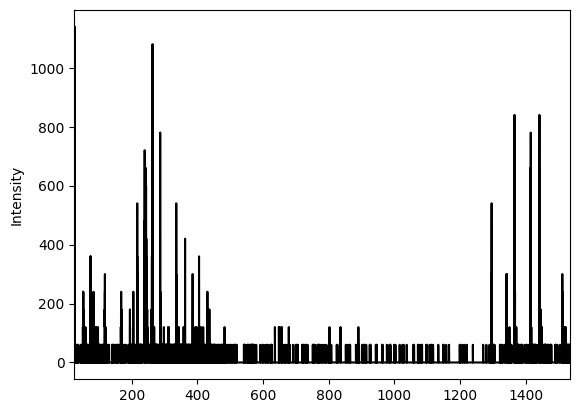

In [5]:
plot_intensity(seq,dt=1/60)

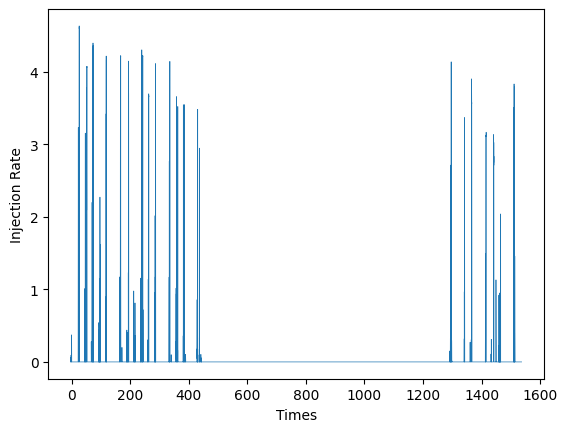

In [6]:
plt.xlabel('Times')
plt.ylabel('Injection Rate')
plt.plot(ts_time, ts,linewidth=0.5,color='tab:blue')

In [7]:
ts_time.shape, ts.shape
ts_time_filtered = ts_time[ts > 10]
print(ts_time_filtered)

tensor([])


In [8]:
t_arr = seq.arrival_times.cpu().numpy()
T0 =0 
T = float(seq.arrival_times.max())
dt =1/60
edges = np.arange(T0, T + dt, dt)

counts, _ = np.histogram(t_arr, bins=edges)
lam = counts / dt

In [9]:
lam.max()

np.float64(1140.0)

In [10]:
neg_index = np.where(ts < 0)
print(neg_index)

(array([], dtype=int64),)


In [11]:
indices = np.nonzero(lam > 500)[0]
indices/60

array([  25.83333333,   25.88333333,   25.91666667,   25.93333333,
         25.96666667,   25.98333333,   26.        ,   26.01666667,
         26.03333333,   26.05      ,   26.06666667,   26.08333333,
         26.1       ,   26.11666667,  216.88333333,  239.3       ,
        239.4       ,  239.5       ,  239.56666667,  239.65      ,
        242.98333333,  243.4       ,  243.48333333,  243.73333333,
        263.18333333,  263.23333333,  263.3       ,  263.31666667,
        263.33333333,  263.35      ,  263.36666667,  263.38333333,
        263.4       ,  263.41666667,  263.43333333,  263.45      ,
        263.46666667,  263.48333333,  263.5       ,  263.51666667,
        263.53333333,  263.55      ,  263.56666667,  263.58333333,
        263.6       ,  263.63333333,  263.66666667,  263.68333333,
        263.7       ,  286.78333333,  286.81666667,  286.85      ,
        286.88333333, 1365.41666667, 1365.53333333, 1365.65      ,
       1365.66666667, 1365.75      , 1365.85      , 1365.86666

In [12]:
ts_count, edges = np.histogram(t_arr, bins=ts_time)
ts_ = (ts[1:]+ts[:-1])/2
ts_time_ = (ts_time[1:] + ts_time[:-1]) / 2

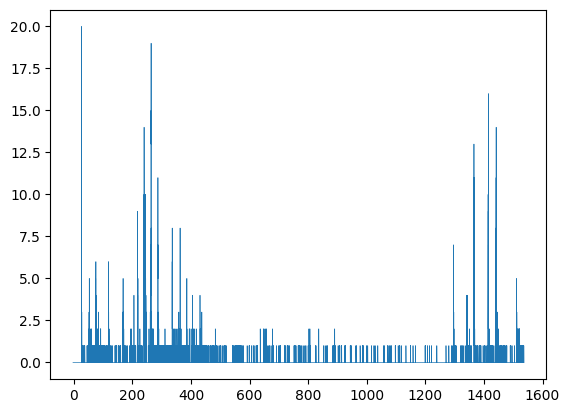

In [13]:
plt.plot(ts_time_, ts_count,linewidth=0.5,color='tab:blue')
# plt.plot(ts_time, ts)

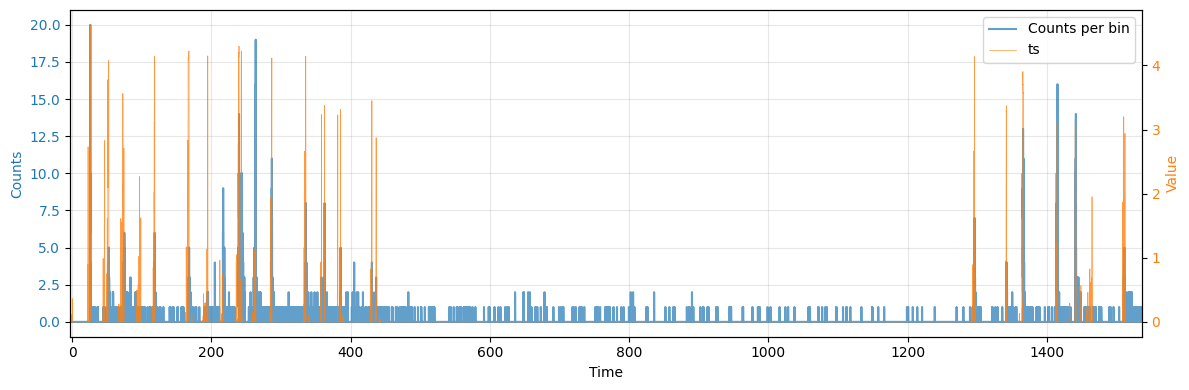

In [14]:
fig, ax1 = plt.subplots(figsize=(12, 4))
l1 = ax1.plot(ts_time[1:].numpy(), ts_count, label="Counts per bin", color="C0", alpha=0.7)
ax1.set_xlabel("Time")
ax1.set_ylabel("Counts", color="C0")
ax1.tick_params(axis="y", labelcolor="C0")
ax1.set_xlim(ts_time.min().item(), ts_time.max().item())
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
l2 = ax2.plot(ts_time_.numpy(), ts_.numpy(), label="ts", color="C1", alpha=0.8,linewidth=0.5)
ax2.set_ylabel("Value", color="C1")
ax2.tick_params(axis="y", labelcolor="C1")

lines = l1 + l2
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="upper right")
fig.tight_layout()

In [15]:
start = pd.to_datetime("2018-10-15 12:00:00")
end1 = pd.to_datetime("2018-10-25 13:28:00")
end2 = pd.to_datetime("2018-10-25 13:55:00")
end3 = pd.to_datetime("2018-10-17 14:00:00")
end4 = pd.to_datetime("2018-12-14 15:00:00")
diff_hour1 = (end1 - start) / pd.Timedelta(hours=1)
diff_hour2 = (end2 - start) / pd.Timedelta(hours=1)
diff_hour3 = (end3 - start) / pd.Timedelta(hours=1)
diff_hour4 = (end4 - start) / pd.Timedelta(hours=1)
print(diff_hour1)
print(diff_hour2)
print(diff_hour3)
print(diff_hour4)


241.46666666666667
241.91666666666666
50.0
1443.0


injection sum: 135.7786865234375, count sum: 627.0, ratio: 4.617808700718062


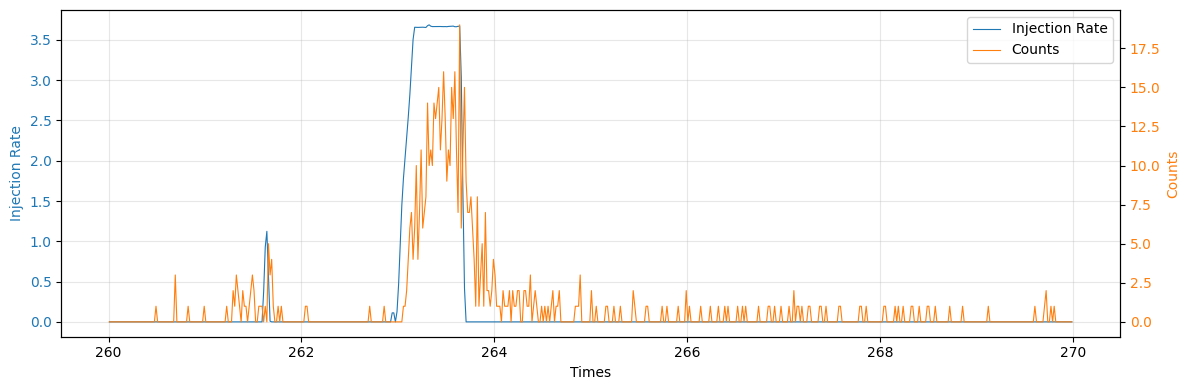

In [16]:
def plot_window(window_start=260, window_len=30, ts_time_=ts_time_, ts_=ts_, ts_count=ts_count, figsize=(12,4), ax=None):
    # convert tensors to numpy once for speed
    t = ts_time_.cpu().numpy() if hasattr(ts_time_, "cpu") else ts_time_.numpy()
    inj = ts_.cpu().numpy() if hasattr(ts_, "cpu") else ts_.numpy()
    counts = ts_count  # already numpy

    window_end = window_start + window_len
    mask = (t >= window_start) & (t <= window_end)
    # mask_ = np.roll(mask, -60)

    if ax is None:
        fig, ax1 = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure
        ax1 = ax

    l1 = ax1.plot(t[mask], inj[mask], label="Injection Rate", color="C0", linewidth=0.8)
    ax1.set_xlabel("Times")
    ax1.set_ylabel("Injection Rate", color="C0")
    ax1.tick_params(axis="y", labelcolor="C0")
    ax1.grid(alpha=0.3)

    ax2 = ax1.twinx()
    l2 = ax2.plot(t[mask], counts[mask], label="Counts", color="C1", linewidth=0.8) 
    ax2.set_ylabel("Counts", color="C1")
    ax2.tick_params(axis="y", labelcolor="C1")

    lines = l1 + l2
    labels = [line.get_label() for line in lines]
    ax1.legend(lines, labels, loc="upper right")
    fig.tight_layout()

    inj_sum = float(inj[mask].sum())
    count_sum = float(counts[mask].sum())
    ratio = count_sum / inj_sum if inj_sum != 0 else float("inf")

    return {"fig": fig, "ax1": ax1, "ax2": ax2, "inj_sum": inj_sum, "count_sum": count_sum, "ratio": ratio}


res = plot_window(window_start=260, window_len=10)
print(f"injection sum: {res['inj_sum']}, count sum: {res['count_sum']}, ratio: {res['ratio']}")